In [2]:
# Download dataset from online source
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

df = pd.read_excel(url)

# Show first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
# Shape of dataset
print("Shape:", df.shape)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Basic stats
df.describe()

Shape: (541909, 8)

Missing Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Convert CustomerID to int (clean format)
df['CustomerID'] = df['CustomerID'].astype(int)

print("After removing missing CustomerID:", df.shape)

After removing missing CustomerID: (406829, 8)


In [6]:
# Remove negative quantity (returns)
df = df[df['Quantity'] > 0]

# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("After removing cancellations:", df.shape)

After removing cancellations: (397924, 8)


In [7]:
df = df[df['UnitPrice'] > 0]

print("After removing invalid prices:", df.shape)

After removing invalid prices: (397884, 8)


In [8]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.4+ MB
None
            Quantity                    InvoiceDate      UnitPrice  \
count  397884.000000                         397884  397884.000000   
mean       12.988238  2011-07-10 23:41:23.511023360       3.116488   
min         1.000000            2010-12-01 08:26

In [11]:
# Get the latest date in dataset
snapshot_date = df['InvoiceDate'].max()

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-09 12:50:00


In [12]:
# Create RFM features
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'TotalPrice': 'sum'  # Monetary
})

# Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,1,77183.60
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


In [13]:
print(rfm.describe())

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     91.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       0.000000     1.000000       3.750000
25%      17.000000     1.000000     307.415000
50%      50.000000     2.000000     674.485000
75%     141.000000     5.000000    1661.740000
max     373.000000   209.000000  280206.020000


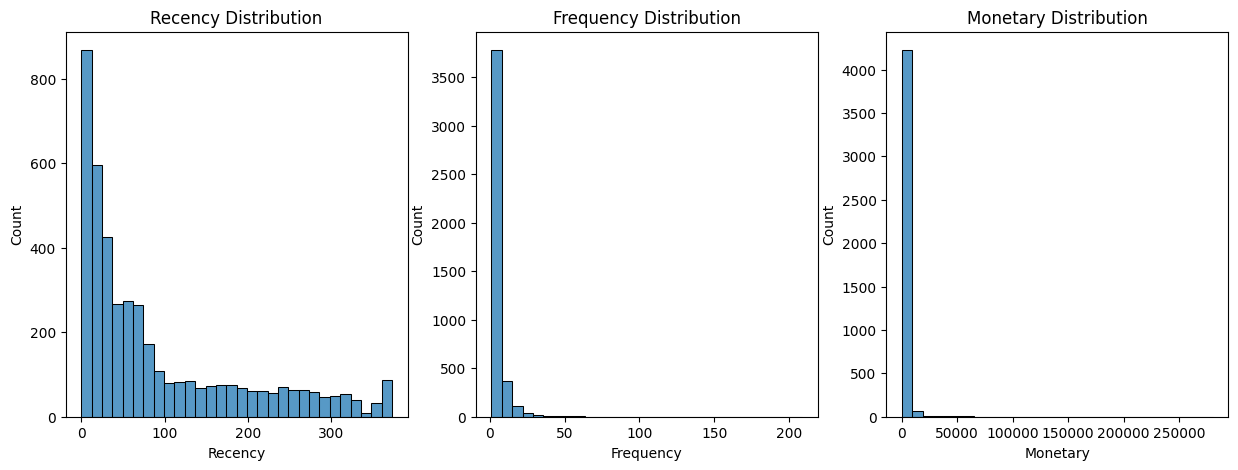

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins=30)
plt.title('Recency Distribution')

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], bins=30)
plt.title('Frequency Distribution')

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins=30)
plt.title('Monetary Distribution')

plt.show()

In [15]:
import numpy as np

rfm_log = np.log1p(rfm)

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,5.786897,0.693147,11.253955
12347,0.693147,2.079442,8.368925
12348,4.317488,1.609438,7.494564
12349,2.944439,0.693147,7.472245
12350,5.736572,0.693147,5.815324


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

# Convert to DataFrame
rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,1.409894,-0.955214,3.706225
12347,-2.146498,1.074425,1.411843
12348,0.383971,0.386304,0.716489
12349,-0.574674,-0.955214,0.698739
12350,1.374758,-0.955214,-0.618962


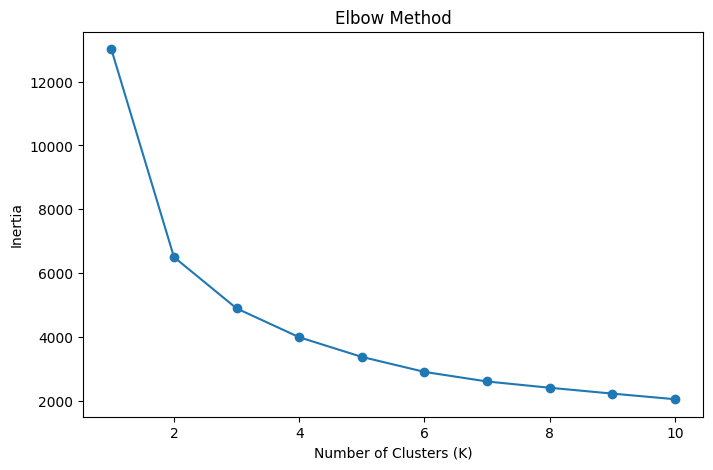

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [18]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.43450909777110786
K=3, Silhouette Score=0.3389072990397626
K=4, Silhouette Score=0.3357442948390719
K=5, Silhouette Score=0.31378135207858904
K=6, Silhouette Score=0.3099475524708476


In [19]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,325,1,77183.60,3
12347,1,7,4310.00,1
12348,74,4,1797.24,3
12349,18,1,1757.55,0
12350,309,1,334.40,2


In [20]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,16.726131,2.119347,544.971897
1,10.659091,13.805398,8142.817287
2,179.601966,1.313268,341.935590
3,69.318182,4.122314,1808.591540


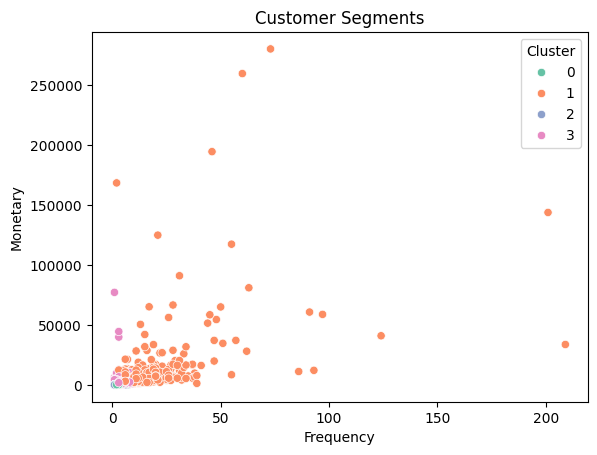

In [21]:
import seaborn as sns

sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='Set2'
)

plt.title("Customer Segments")
plt.show()

In [22]:
# Define churn (threshold: > 90 days inactive)
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Churn
CustomerID,,,,,
12346,325,1,77183.60,3,1
12347,1,7,4310.00,1,0
12348,74,4,1797.24,3,0
12349,18,1,1757.55,0,0
12350,309,1,334.40,2,1


In [23]:
rfm['Churn'].value_counts()

,count
Churn,
0,2893
1,1445


In [24]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       561
           1       1.00      1.00      1.00       307

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



This is called: Data **Leakage**

In [29]:
X = rfm[['Frequency', 'Monetary']]  # Removed Recency
y = rfm['Churn']

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7131336405529954

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.80      0.78       561
           1       0.60      0.55      0.58       307

    accuracy                           0.71       868
   macro avg       0.68      0.68      0.68       868
weighted avg       0.71      0.71      0.71       868



In [31]:
def label_cluster(row):
    if row['Cluster'] == 1:
        return 'VIP Customers'
    elif row['Cluster'] == 3:
        return 'Loyal Customers'
    elif row['Cluster'] == 0:
        return 'New Customers'
    else:
        return 'At Risk Customers'

rfm['Segment'] = rfm.apply(label_cluster, axis=1)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Churn,Segment
CustomerID,,,,,,
12346,325,1,77183.60,3,1,Loyal Customers
12347,1,7,4310.00,1,0,VIP Customers
12348,74,4,1797.24,3,0,Loyal Customers
12349,18,1,1757.55,0,0,New Customers
12350,309,1,334.40,2,1,At Risk Customers


In [32]:
rfm.groupby('Segment').mean()

,Recency,Frequency,Monetary,Cluster,Churn
Segment,,,,,
At Risk Customers,179.601966,1.313268,341.935590,2.0,0.709459
Loyal Customers,69.318182,4.122314,1808.591540,3.0,0.238843
New Customers,16.726131,2.119347,544.971897,0.0,0.000000
VIP Customers,10.659091,13.805398,8142.817287,1.0,0.001420


In [33]:
rfm['Segment'].value_counts()

,count
Segment,
At Risk Customers,1628
Loyal Customers,1210
New Customers,796
VIP Customers,704
